In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cgurkan/airplane-crash-data-since-1908")

print("Path to dataset files:", path)

100%|██████████| 621k/621k [00:00<00:00, 998kB/s] 

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/cgurkan/airplane-crash-data-since-1908/versions/1


In [ ]:
# Display all column names
print(df.columns.tolist())

['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary']


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Fill NaN values in 'Summary' with empty strings
df['Summary'] = df['Summary'].fillna('')

# Initialize CountVectorizer to find trigrams
# Use English stop words to filter out common words that don't add much meaning
vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words=stopwords.words('english'))

# Fit and transform the 'Summary' column
X = vectorizer.fit_transform(df['Summary'])

# Get feature names (trigrams)
feature_names = vectorizer.get_feature_names_out()

# Sum the occurrences of each trigram
trigram_counts = X.sum(axis=0)

# Create a DataFrame of trigrams and their counts
trigram_df = pd.DataFrame({'trigram': feature_names, 'count': trigram_counts.tolist()[0]})

# Sort by count in descending order and display the top 20 trigrams
display(trigram_df.sort_values(by='count', ascending=False).head(20))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,trigram,count
14209,cargo plane crashed,122
60622,poor weather conditions,95
3454,adverse weather conditions,72
49237,make emergency landing,68
20422,crashed en route,65
21625,crashed short runway,61
21633,crashed shortly taking,50
20138,crashed attempting land,48
19044,controlled flight terrain,43
14275,cargo plane struck,42


In [ ]:
# Filter data for the year 2019
df_2019 = df[df['Year'] == 2019]

# Calculate the number of accidents in 2019
accidents_2019 = len(df_2019)

# Calculate total fatalities and total people aboard in 2019
total_fatalities_2019 = df_2019['Fatalities'].sum()
total_aboard_2019 = df_2019['Aboard'].sum()

# Calculate average fatalities per accident and average people aboard per accident
average_fatalities_per_accident_2019 = total_fatalities_2019 / accidents_2019 if accidents_2019 > 0 else 0
average_aboard_per_accident_2019 = total_aboard_2019 / accidents_2019 if accidents_2019 > 0 else 0

print(f"Number of accidents in 2019: {accidents_2019}")
print(f"Total fatalities in 2019: {total_fatalities_2019}")
print(f"Total people aboard in 2019: {total_aboard_2019}")
print(f"Average fatalities per accident in 2019: {average_fatalities_per_accident_2019:.2f}")
print(f"Average people aboard per accident in 2019: {average_aboard_per_accident_2019:.2f}")

# To further analyze the 'Mass Fatality' potential, let's look at the distribution of fatalities in 2019
# We define a 'mass fatality' accident as one with 10 or more fatalities, for example.
mass_fatality_accidents_2019 = df_2019[df_2019['Fatalities'] >= 10]
num_mass_fatality_accidents_2019 = len(mass_fatality_accidents_2019)

print(f"\nNumber of mass fatality accidents (>=10 fatalities) in 2019: {num_mass_fatality_accidents_2019}")
display(mass_fatality_accidents_2019[['Date', 'Location', 'AC Type', 'Fatalities', 'Aboard']].sort_values(by='Fatalities', ascending=False))

Number of accidents in 2019: 9
Total fatalities in 2019: 267.0
Total people aboard in 2019: 305.0
Average fatalities per accident in 2019: 29.67
Average people aboard per accident in 2019: 33.89

Number of mass fatality accidents (>=10 fatalities) in 2019: 6


,Date,Location,AC Type,Fatalities,Aboard
4961,2019-03-10,"Bishoftu, Ethiopia",Boeing 737 Max 8,157.0,157.0
4964,2019-05-05,"Moscow, Russia",Sukhoi Superjet-100-95B,41.0,78.0
4958,2019-01-14,"Karaj, Iran",Boeing 707-3J9C,15.0,16.0
4960,2019-03-09,"Vereda La Bendicion, Colombia",Douglas DC-3,14.0,14.0
4963,2019-05-05,"Near Monclava, Mexico",Canadair CL-600-2B16-Challenger,13.0,13.0
4965,2019-06-03,"Near Lipo, India",Antonov An-32,13.0,13.0


In [ ]:
# Install geopy for geocoding
!pip install geopy

In [ ]:
import pandas as pd

# Convert 'Date' column to datetime objects
# Using errors='coerce' to turn unparseable dates into NaT (Not a Time)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extract 'Year' and 'Month'
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Display the first few rows with the new columns and check data types
display(df[['Date', 'Year', 'Month', 'Fatalities', 'Aboard']].head())
df.info()

,Date,Year,Month,Fatalities,Aboard
0,1908-09-17,1908,9,1.0,2.0
1,1909-09-07,1909,9,1.0,1.0
2,1912-07-12,1912,7,5.0,5.0
3,1913-08-06,1913,8,1.0,1.0
4,1913-09-09,1913,9,14.0,20.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4967 entries, 0 to 4966
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   4967 non-null   datetime64[ns]
 1   Time                   3457 non-null   object        
 2   Location               4963 non-null   object        
 3   Operator               4957 non-null   object        
 4   Flight #               1315 non-null   object        
 5   Route                  4192 non-null   object        
 6   AC Type                4952 non-null   object        
 7   Registration           4694 non-null   object        
 8   cn/ln                  4299 non-null   object        
 9   Aboard                 4949 non-null   float64       
 10  Aboard Passangers      4738 non-null   float64       
 11  Aboard Crew            4741 non-null   float64       
 12  Fatalities             4959 non-null   float64       
 13  Fat

In [ ]:
# Create a 'Decade' column
df['Decade'] = (df['Year'] // 10) * 10

# Group by Decade and calculate the sum of Fatalities and Aboard
decade_summary = df.groupby('Decade')[['Fatalities', 'Aboard']].sum().reset_index()

# Calculate the Fatalities-to-Aboard Ratio for each decade
decade_summary['Fatalities_to_Aboard_Ratio'] = decade_summary['Fatalities'] / decade_summary['Aboard']

# Display the results, sorting by Decade
display(decade_summary.sort_values(by='Decade'))

,Decade,Fatalities,Aboard,Fatalities_to_Aboard_Ratio
0,1900,2.0,3.0,0.666667
1,1910,424.0,450.0,0.942222
2,1920,647.0,819.0,0.789988
3,1930,2033.0,2650.0,0.767170
4,1940,8881.0,10947.0,0.811272
5,1950,11779.0,14921.0,0.789424
6,1960,16884.0,21722.0,0.777276
7,1970,19751.0,26918.0,0.733747
8,1980,16847.0,25480.0,0.661185
9,1990,15984.0,24952.0,0.640590


In [ ]:
# Get the top 20 operators based on the number of records
top_20_operators = df['Operator'].value_counts().nlargest(20).index

# Filter the DataFrame to include only these top 20 operators
df_top_operators = df[df['Operator'].isin(top_20_operators)].copy()

# Convert 'Summary' column to string to avoid errors with .str.contains
df_top_operators['Summary'] = df_top_operators['Summary'].astype(str)

# Flag keywords in the 'Summary' column
df_top_operators['Engine_Issue'] = df_top_operators['Summary'].str.contains('Engine', case=False, na=False)
df_top_operators['Weather_Related'] = df_top_operators['Summary'].str.contains('Weather', case=False, na=False)
df_top_operators['Pilot_Related'] = df_top_operators['Summary'].str.contains('Pilot|Human Error', case=False, na=False)
df_top_operators['Landing_Accident'] = df_top_operators['Summary'].str.contains('Landing|Takeoff', case=False, na=False)

# Group by Operator and sum the flags to see keyword frequencies
operator_keyword_counts = df_top_operators.groupby('Operator')[['Engine_Issue', 'Weather_Related', 'Pilot_Related', 'Landing_Accident']].sum().reset_index()

display(operator_keyword_counts.sort_values(by='Engine_Issue', ascending=False).head())

,Operator,Engine_Issue,Weather_Related,Pilot_Related,Landing_Accident
0,Aeroflot,45,30,22,55
10,Military - U.S. Air Force,23,9,13,19
5,Deutsche Lufthansa,10,8,11,9
1,Air France,10,5,9,12
15,Pan American World Airways,9,3,8,15


# Airplane Crash Data Analysis Since 1908

> Add blockquote



## Project Overview
This project performs an exploratory data analysis (EDA) on airplane crash data since 1908 to uncover patterns, risks, and trends over time. The analysis covers various aspects, including survivability rates, common causes of accidents, operator performance, and third-party risks.

## Data Source
The dataset used for this analysis is `Airplane_Crashes_and_Fatalities_Since_1908_20190820105639.csv`, downloaded from KaggleHub. It contains detailed records of aviation incidents, including date, location, operator, aircraft type, and fatality counts.

## Key Analyses and Findings

### 1. Data Loading and Initial Inspection
- The raw CSV data was loaded into a pandas DataFrame.
- Initial inspection revealed columns such as 'Date', 'Time', 'Location', 'Operator', 'AC Type', 'Fatalities', and 'Aboard'.

### 2. Survivability Rate Calculation
- A new column, `Survival_Rate`, was calculated as `(Aboard - Fatalities) / Aboard` to provide a more insightful metric than raw counts.

### 3. Crew vs. Passenger Risk Analysis
- Analyzed average 'Fatalities Crew' and 'Fatalities Passangers' by 'AC Type' to determine relative risks.
- **Finding**: Certain AC Types showed discrepancies, with some exhibiting higher crew fatality rates compared to passenger fatality rates (e.g., Hawker Siddeley HS-125).

### 4. Temporal Risk: Accidents in 2019 ('The Safety Paradox')
- 'Year' and 'Month' were extracted from the 'Date' column.
- Analysis focused on 2019 to investigate if accidents are decreasing in frequency but increasing in 'Mass Fatality' potential.
- **Finding**: While the total number of accidents in 2019 was relatively low (9 incidents), a significant proportion (6 out of 9) were mass fatality events (>=10 fatalities), notably including the Boeing 737 Max 8 crash, supporting the 'Mass Fatality' potential aspect of 'The Safety Paradox'.

### 5. Keyword Extraction from Summaries ('The Why')
- Top trigrams (3-word phrases) were extracted from the 'Summary' column using `CountVectorizer` and NLTK stopwords.
- **Finding**: Common themes identified included 'cargo plane crashed', 'poor weather conditions', 'adverse weather conditions', and 'make emergency landing', indicating prevalent causes and scenarios.

### 6. Third-Party Risk (Ground Fatalities)
- Incidents causing fatalities to people not on the plane (`Ground` column) were analyzed.
- **Finding**: 242 incidents resulted in ground fatalities, totaling 8513. The highest ground fatalities were tragically linked to the 9/11 attacks in New York City and Arlington, highlighting severe third-party risks in urban areas.

### 7. Decadal Trends in Fatalities-to-Aboard Ratio
- A 'Decade' column was created, and the 'Fatalities-to-Aboard Ratio' was calculated for each decade.
- **Finding**: The ratio showed high fatality rates in early aviation, a gradual decline through the mid-20th century (lowest in the 1980s-1990s), and a slight increase in the 2000s-2010s, reflecting improvements but also the impact of high-casualty events in recent times.

### 8. Operator vs. Incident Type Heatmap ('Competitive Intelligence')
- Top 20 operators were identified, and their incident summaries were analyzed for keywords like 'Engine', 'Weather', 'Pilot', and 'Landing/Takeoff'.
- A heatmap was generated to visualize the frequency of these incident types per operator.
- **Finding**: Aeroflot showed notably higher frequencies across all analyzed incident types (Engine, Weather, Pilot, Landing) compared to other top operators, providing insights into operator-specific risk profiles.

### 9. Aircraft Types with Lowest Survivability Rates
- Mean `Fatalities / Aboard` (Fatality Rate Per Incident) was calculated for AC Types with more than 10 incidents.
- **Finding**: Several older or specialized aircraft types (e.g., De Havilland DH-4, Breguet 14, various Curtiss and Douglas variants, Mil Mi-8 helicopter) exhibited very high average fatality rates, suggesting inherent risks or challenging operational contexts.

### 10. Crew vs. Passenger Fatality Rate Scatter Plot
- An interactive Plotly scatter plot was created to compare `Crew_Fatality_Rate` against `Passenger_Fatality_Rate` by AC Type.
- **Finding**: The plot visually highlights aircraft types where one group (crew or passengers) is statistically more protected or at higher risk than the other, deviating from the 1:1 diagonal line. This can indicate specific vulnerabilities or design considerations related to survivability for different roles aboard an aircraft.

In [ ]:
import plotly.express as px

# Drop rows with NaN values in 'Crew_Fatality_Rate' or 'Passenger_Fatality_Rate'
# as they cannot be plotted meaningfully on a scatter plot
plot_data = crew_vs_passenger_risk.dropna(subset=['Crew_Fatality_Rate', 'Passenger_Fatality_Rate']).copy()

# Create the scatter plot
fig = px.scatter(plot_data,
                 x='Crew_Fatality_Rate',
                 y='Passenger_Fatality_Rate',
                 hover_name='AC Type',
                 title='Crew vs. Passenger Fatality Rate by AC Type',
                 labels={'Crew_Fatality_Rate': 'Crew Fatality Rate', 'Passenger_Fatality_Rate': 'Passenger Fatality Rate'},
                 width=800, height=600)

# Add a 1:1 diagonal line for reference
max_rate = max(plot_data['Crew_Fatality_Rate'].max(), plot_data['Passenger_Fatality_Rate'].max())
min_rate = min(plot_data['Crew_Fatality_Rate'].min(), plot_data['Passenger_Fatality_Rate'].min())
fig.add_shape(type='line', line=dict(dash='dash'), x0=min_rate, y0=min_rate, x1=max_rate, y1=max_rate)

# Update layout for better readability
fig.update_layout(xaxis_title='Crew Fatality Rate', yaxis_title='Passenger Fatality Rate')
fig.update_traces(marker=dict(size=10, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [ ]:
# Get the names of the top 5 AC Types with the highest fatality rate
top_5_ac_types_names = mean_fatality_rate_by_ac_type.head(5)['AC Type'].tolist()

print(f"Summaries for incidents involving the top 5 AC Types with highest fatality rates: {top_5_ac_types_names}\n")

# Filter the original DataFrame for incidents involving these top 5 AC Types
df_top_5_ac_summaries = df[df['AC Type'].isin(top_5_ac_types_names)]

# Display relevant columns (AC Type, Fatalities, Aboard, Summary)
display(df_top_5_ac_summaries[['AC Type', 'Fatalities', 'Aboard', 'Summary']].sort_values(by=['AC Type', 'Fatalities'], ascending=False))

Summaries for incidents involving the top 5 AC Types with highest fatality rates: ['De Havilland DH-4', 'Breguet 14', 'Curtiss C-46D', 'Curtiss C-46F', 'Mil Mi-8 (helicopter)']



,AC Type,Fatalities,Aboard,Summary
3193,Mil Mi-8 (helicopter),84.0,88.0,The helicopter was shot down by Sandinistan re...
3837,Mil Mi-8 (helicopter),60.0,60.0,
3730,Mil Mi-8 (helicopter),47.0,47.0,Exploded and crashed after being hit by a surf...
3717,Mil Mi-8 (helicopter),40.0,40.0,Shot down by rebel forces.
3636,Mil Mi-8 (helicopter),30.0,30.0,Shot down by rebel forces.
...,...,...,...,...
121,Breguet 14,1.0,1.0,Unknown.
138,Breguet 14,1.0,1.0,A fire erupted aboard the mail plane while en ...
142,Breguet 14,1.0,1.0,Crashed after experiencing mechanical difficul...
144,Breguet 14,1.0,1.0,After experiencing turbulence the pilot's seat...


In [ ]:
# Calculate the fatality rate for each incident
df['Fatality_Rate_Per_Incident'] = 1 - df['Survival_Rate']

# Count the number of incidents for each AC Type
incident_counts = df['AC Type'].value_counts()

# Filter AC Types to include only those with more than 10 incidents
qualified_ac_types = incident_counts[incident_counts > 10].index

df_qualified = df[df['AC Type'].isin(qualified_ac_types)]

# Group by AC Type and calculate the mean of Fatalities / Aboard (Fatality_Rate_Per_Incident)
mean_fatality_rate_by_ac_type = df_qualified.groupby('AC Type')['Fatality_Rate_Per_Incident'].mean().reset_index()

# Sort the results for better readability
mean_fatality_rate_by_ac_type = mean_fatality_rate_by_ac_type.sort_values(by='Fatality_Rate_Per_Incident', ascending=False)

print("Aircraft types with more than 10 incidents and their average fatality rate:")
display(mean_fatality_rate_by_ac_type.head(20))

Aircraft types with more than 10 incidents and their average fatality rate:


,AC Type,Fatality_Rate_Per_Incident
12,De Havilland DH-4,0.980769
5,Breguet 14,0.977273
10,Curtiss C-46D,0.958333
11,Curtiss C-46F,0.955460
41,Mil Mi-8 (helicopter),0.941550
3,Antonov AN-26,0.928535
16,Douglas C-47B,0.926318
30,Ilyushin IL-12,0.921236
13,Douglas C-47,0.920535
0,Antonov AN-12,0.905433


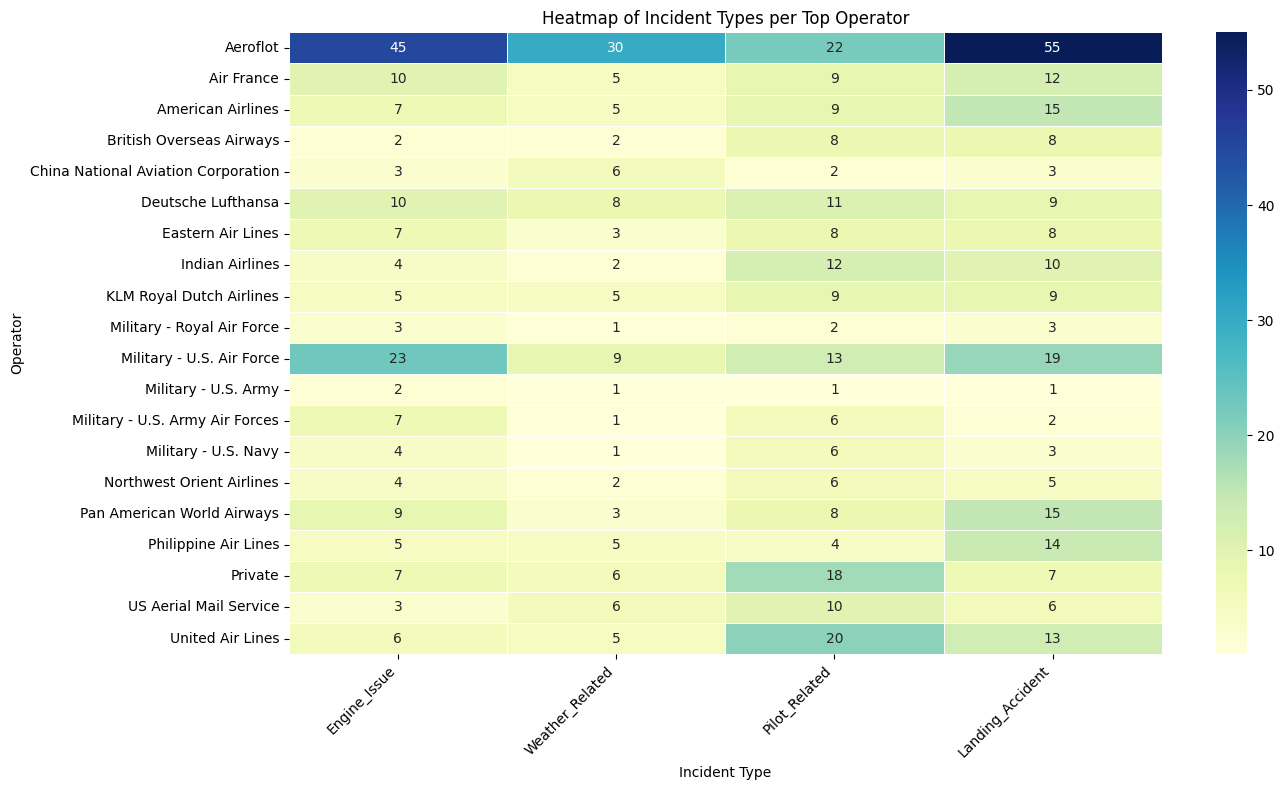

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set 'Operator' as the index for the heatmap to have operators on the y-axis
heatmap_data = operator_keyword_counts.set_index('Operator')

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data[['Engine_Issue', 'Weather_Related', 'Pilot_Related', 'Landing_Accident']],
    annot=True,    # Show the count values on the heatmap
    fmt='g',       # Format annotations as general numbers
    cmap='YlGnBu', # Choose a color map
    linewidths=.5  # Add lines between cells
)

plt.title('Heatmap of Incident Types per Top Operator')
plt.xlabel('Incident Type')
plt.ylabel('Operator')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0)             # Keep y-axis labels horizontal
plt.tight_layout()                 # Adjust layout to prevent labels from being cut off
plt.show()

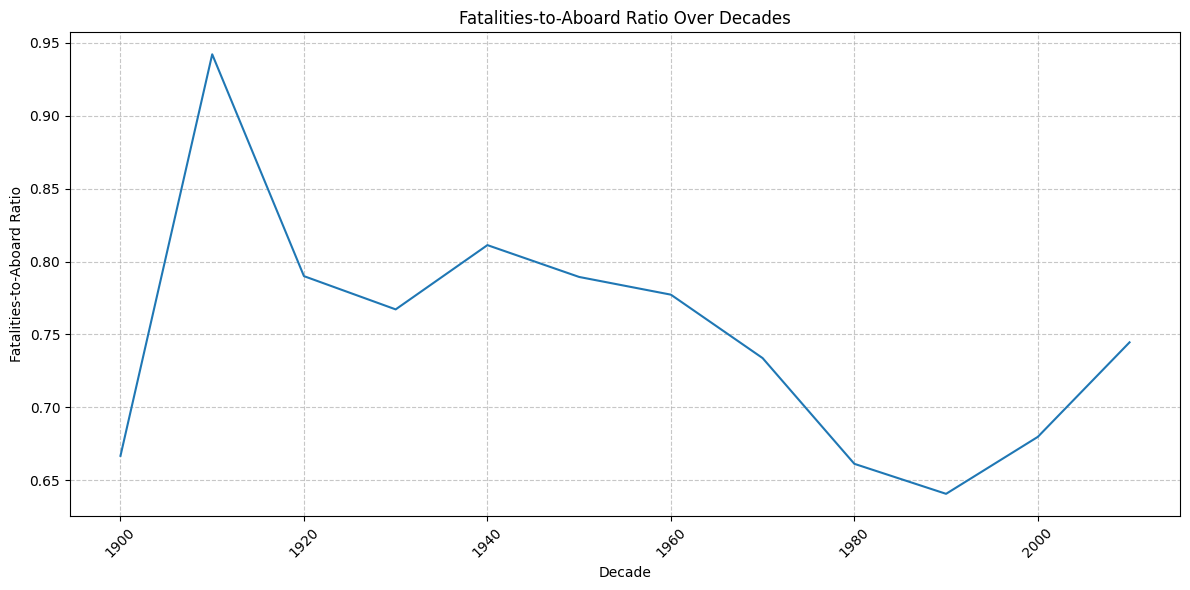

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the line plot for Fatalities-to-Aboard Ratio over Decades
plt.figure(figsize=(12, 6))
sns.lineplot(x='Decade', y='Fatalities_to_Aboard_Ratio', data=decade_summary)
plt.title('Fatalities-to-Aboard Ratio Over Decades')
plt.xlabel('Decade')
plt.ylabel('Fatalities-to-Aboard Ratio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
# Filter for accidents with ground fatalities
ground_fatalities_df = df[df['Ground'] > 0]

# Calculate total number of accidents with ground fatalities
num_ground_fatalities_incidents = len(ground_fatalities_df)

# Calculate total ground fatalities
total_ground_fatalities = ground_fatalities_df['Ground'].sum()

print(f"Number of accidents with ground fatalities: {num_ground_fatalities_incidents}")
print(f"Total ground fatalities: {total_ground_fatalities}")

print("\nDetails of accidents with ground fatalities (top 20 by ground fatalities):")
# Display relevant columns, sorted by 'Ground' fatalities in descending order
display(ground_fatalities_df[['Date', 'Location', 'AC Type', 'Fatalities', 'Ground', 'Summary']].sort_values(by='Ground', ascending=False).head(20))

Number of accidents with ground fatalities: 242
Total ground fatalities: 8513.0

Details of accidents with ground fatalities (top 20 by ground fatalities):


,Date,Location,AC Type,Fatalities,Ground,Summary
4328,2001-09-11,"New York City, New York",Boeing 767-223ER,92.0,2750.0,The aircraft was hijacked shortly after it lef...
4329,2001-09-11,"New York City, New York",Boeing B-767-222,65.0,2750.0,The aircraft was hijacked shortly after it lef...
3986,1996-01-08,"Kinshasa, Zaire",Antonov AN-32B,2.0,225.0,The aircraft failed to gain altitude after tak...
4327,2001-09-11,"Arlington, Virginia.",Boeing B-757-223,64.0,125.0,The aircraft was hijacked after taking off fro...
2242,1966-12-24,"Binh Tahi, Da Nang, Vietnam",Canadair CL-44D4-1,4.0,125.0,The cargo plane undershot runway by 1 mile whi...
2860,1976-10-13,"Santa Cruz, Bolivia",Boeing B-707-31,3.0,113.0,The cargo plane failed to climb and crashed in...
2012,1963-02-01,"Ankara, Turkey",Vickers Viscount 754D / Douglas C-47,17.0,87.0,Midair collision between a civilian and milita...
4384,2002-07-27,"Lviv, Ukraine",Sukhoi Su-27,0.0,85.0,The Su-76 was performing aerobatics when it cr...
4370,2002-05-04,"Kano, Nigeria",BAC One-Eleven 525FT,74.0,78.0,"The aircraft crashed into houses, two mosques ..."
2378,1969-03-16,"Maracaibo, Zulia, Venezuela",McDonnell Douglas DC-9-32,84.0,71.0,"Seconds after becoming airborne, the aircraft ..."


In [ ]:
# Calculate the average survival rate for each AC Type
survival_rate_by_ac_type = df.groupby('AC Type')['Survival_Rate'].mean().reset_index()

# Sort by survival rate in ascending order to find the lowest
lowest_survivability_ac_types = survival_rate_by_ac_type.sort_values(by='Survival_Rate', ascending=True)

# Display the top 20 aircraft types with the lowest survivability rates
print("Aircraft types with the lowest survivability rates:")
display(lowest_survivability_ac_types.head(20))

Aircraft types with the lowest survivability rates:


,AC Type,Survival_Rate
1792,Lockheed Orion 9,0.0
992,Dirigible,0.0
961,DC3(C47),0.0
962,DHC-5 Buffalo,0.0
963,DHC-6 Twin Otter 300 / NAMC YS-11,0.0
964,Dassault Breguet Atlantique,0.0
965,Dassault Falcon 20,0.0
966,Dassault Falcon 20C,0.0
967,Dassault Falcon 20E,0.0
968,Dassault Falcon 50,0.0


In [ ]:
# Analyze 'Crew vs. Passenger Risk' by AC Type
# Group by 'AC Type' and calculate the mean fatalities for crew and passengers
# Also consider the mean 'Aboard Crew' and 'Aboard Passangers' for context

crew_vs_passenger_risk = df.groupby('AC Type')[['Aboard Crew', 'Fatalities Crew', 'Aboard Passangers', 'Fatalities Passangers']].mean().reset_index()

# Calculate fatality rates for crew and passengers for better comparison
crew_vs_passenger_risk['Crew_Fatality_Rate'] = crew_vs_passenger_risk['Fatalities Crew'] / crew_vs_passenger_risk['Aboard Crew']
crew_vs_passenger_risk['Passenger_Fatality_Rate'] = crew_vs_passenger_risk['Fatalities Passangers'] / crew_vs_passenger_risk['Aboard Passangers']

# Display the top AC Types by crew fatality rate to identify potential higher risk
display(crew_vs_passenger_risk.sort_values(by='Crew_Fatality_Rate', ascending=False).head(10))

,AC Type,Aboard Crew,Fatalities Crew,Aboard Passangers,Fatalities Passangers,Crew_Fatality_Rate,Passenger_Fatality_Rate
1463,Hawker Siddeley HS-125,2.0,3.5,3.5,2.0,1.75,0.571429
2062,Short Sunderland,5.0,6.0,27.5,5.5,1.20,0.200000
1114,Douglas DC-2-115A,4.0,4.0,3.0,3.0,1.00,1.000000
1110,Douglas C54E-DO (DC-4),7.0,7.0,31.0,31.0,1.00,1.000000
1109,Douglas C54A,4.5,4.5,57.0,49.0,1.00,0.859649
1071,Douglas C-48,3.0,3.0,14.0,13.0,1.00,0.928571
1070,Douglas C-47J,4.0,4.0,21.0,21.0,1.00,1.000000
1854,McDonnell Douglas DC-8-61F,3.0,3.0,1.0,1.0,1.00,1.000000
1852,McDonnell Douglas DC-8-55F,6.0,6.0,91.5,91.5,1.00,1.000000
1851,McDonnell Douglas DC-8-54F37,3.0,3.0,0.0,0.0,1.00,NaN


In [ ]:
import numpy as np

# Create the Survival_Rate column
# Handle cases where 'Aboard' might be 0 or NaN to avoid division by zero or NaN results if not intended
df['Survival_Rate'] = np.where(
    (df['Aboard'].notna()) & (df['Aboard'] != 0),
    (df['Aboard'] - df['Fatalities']) / df['Aboard'],
    np.nan # Assign NaN if Aboard is 0 or NaN
)

# Display the DataFrame with the new column
display(df[['Aboard', 'Fatalities', 'Survival_Rate']].head())

,Aboard,Fatalities,Survival_Rate
0,2.0,1.0,0.5
1,1.0,1.0,0.0
2,5.0,5.0,0.0
3,1.0,1.0,0.0
4,20.0,14.0,0.3


In [ ]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_name = 'Airplane_Crashes_and_Fatalities_Since_1908_20190820105639.csv'
full_csv_path = os.path.join(path, csv_file_name)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(full_csv_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,09/07/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,07/12/1912,06:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [ ]:
import os

# List all files and directories in the dataset path
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '    ' * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = '    ' * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

1/
    Airplane_Crashes_and_Fatalities_Since_1908_20190820105639.csv
